# Machine Learning

## Importing libraries

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

## Load data frames

In [51]:
df_music = pd.read_pickle("../data/processed/df_music_features.pkl")
track_summary = pd.read_pickle("../data/processed/track_summary.pkl")
audio_features_df = pd.read_pickle("../data/processed/audio_features.pkl")

In [52]:
track_summary.head()

,track_id,play_count,minutes_played
3,004X2kXNoGFFZnrWlcYLuF,7,6.378650
7,0075v1NLfKBzSBvJauGCrF,8,20.537367
12,00A4EYZsl3a1sF65zurTWr,5,9.036083
17,00Amd2EiGo17YoZyOjk3VV,6,20.361133
18,00B7SBwrjbycLMOgAmeIU8,5,12.932933


In [53]:
audio_features_df.head()

,acousticness,analysis_url,danceability,duration_ms,energy,id,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,track_href,type,uri,valence
0,0.13900,https://api.spotify.com/v1/audio-analysis/004X...,0.601,123813,0.569,004X2kXNoGFFZnrWlcYLuF,0.000000,0,0.2380,-8.074,1,0.0316,139.804,4,https://api.spotify.com/v1/tracks/004X2kXNoGFF...,audio_features,spotify:track:004X2kXNoGFFZnrWlcYLuF,0.189
1,0.03900,https://api.spotify.com/v1/audio-analysis/0075...,0.451,199999,0.977,0075v1NLfKBzSBvJauGCrF,0.000978,11,0.2630,-4.182,0,0.0749,178.000,4,https://api.spotify.com/v1/tracks/0075v1NLfKBz...,audio_features,spotify:track:0075v1NLfKBzSBvJauGCrF,0.598
2,0.02480,https://api.spotify.com/v1/audio-analysis/00A4...,0.628,199245,0.956,00A4EYZsl3a1sF65zurTWr,0.836000,9,0.2510,-1.461,1,0.1340,105.987,4,https://api.spotify.com/v1/tracks/00A4EYZsl3a1...,audio_features,spotify:track:00A4EYZsl3a1sF65zurTWr,0.125
3,0.35800,https://api.spotify.com/v1/audio-analysis/00Am...,0.445,354333,0.628,00Amd2EiGo17YoZyOjk3VV,0.686000,0,0.0949,-11.268,1,0.0623,81.248,4,https://api.spotify.com/v1/tracks/00Amd2EiGo17...,audio_features,spotify:track:00Amd2EiGo17YoZyOjk3VV,0.396
4,0.00745,https://api.spotify.com/v1/audio-analysis/00B7...,0.663,251589,0.710,00B7SBwrjbycLMOgAmeIU8,0.005590,11,0.1470,-5.550,0,0.0599,120.984,4,https://api.spotify.com/v1/tracks/00B7SBwrjbyc...,audio_features,spotify:track:00B7SBwrjbycLMOgAmeIU8,0.487


## Create data frame for analysis

Merge data frames to contain audio features and track id's

In [54]:
track_summary.shape, audio_features_df.shape

((8410, 3), (8404, 18))

In [55]:
analysis_df = track_summary.merge(
    audio_features_df,
    left_on="track_id",
    right_on="id",
    how="inner"
)

In [56]:
analysis_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8404 entries, 0 to 8403
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track_id          8404 non-null   str    
 1   play_count        8404 non-null   int64  
 2   minutes_played    8404 non-null   float64
 3   acousticness      8404 non-null   float64
 4   analysis_url      8404 non-null   str    
 5   danceability      8404 non-null   float64
 6   duration_ms       8404 non-null   int64  
 7   energy            8404 non-null   float64
 8   id                8404 non-null   str    
 9   instrumentalness  8404 non-null   float64
 10  key               8404 non-null   int64  
 11  liveness          8404 non-null   float64
 12  loudness          8404 non-null   float64
 13  mode              8404 non-null   int64  
 14  speechiness       8404 non-null   float64
 15  tempo             8404 non-null   float64
 16  time_signature    8404 non-null   int64  
 17  track_

In [57]:
analysis_df.isna().sum()

track_id            0
play_count          0
minutes_played      0
acousticness        0
analysis_url        0
danceability        0
duration_ms         0
energy              0
id                  0
instrumentalness    0
key                 0
liveness            0
loudness            0
mode                0
speechiness         0
tempo               0
time_signature      0
track_href          0
type                0
uri                 0
valence             0
dtype: int64

In [58]:
analysis_df.describe()

,play_count,minutes_played,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
count,8404.000000,8404.000000,8404.000000,8404.000000,8.404000e+03,8404.000000,8404.000000,8404.000000,8404.000000,8404.000000,8404.000000,8404.000000,8404.000000,8404.000000,8404.000000
mean,8.548667,27.108493,0.109881,0.461212,2.665547e+05,0.779222,0.151823,5.329843,0.222308,-6.866612,0.565802,0.075770,127.193486,3.918134,0.407848
std,5.955676,25.435803,0.218204,0.155908,1.190173e+05,0.204630,0.280518,3.533584,0.184056,3.449113,0.495681,0.069658,29.069690,0.375635,0.229411
min,4.000000,0.021400,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,-36.756000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.000000,12.392008,0.000385,0.349000,2.016545e+05,0.677000,0.000008,2.000000,0.099900,-8.139000,0.000000,0.037500,105.032750,4.000000,0.226000
50%,6.000000,19.760925,0.006445,0.463000,2.429805e+05,0.850000,0.002150,5.000000,0.149000,-6.066000,1.000000,0.052700,126.100500,4.000000,0.379000
75%,10.000000,33.331904,0.085725,0.561000,3.024702e+05,0.937000,0.122000,9.000000,0.300000,-4.636000,1.000000,0.087000,146.239000,4.000000,0.567000
max,58.000000,476.993067,1.000000,0.971000,1.766733e+06,1.000000,0.995000,11.000000,0.999000,-0.329000,1.000000,0.963000,238.895000,5.000000,0.977000


For machine learning, drop all unnecessary columns.

In [59]:
drop_cols = [
    "track_id",
    "id",
    "analysis_url",
    "track_href",
    "type",
    "uri"
]

ml_df = analysis_df.drop(columns=drop_cols)

In [60]:
ml_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8404 entries, 0 to 8403
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   play_count        8404 non-null   int64  
 1   minutes_played    8404 non-null   float64
 2   acousticness      8404 non-null   float64
 3   danceability      8404 non-null   float64
 4   duration_ms       8404 non-null   int64  
 5   energy            8404 non-null   float64
 6   instrumentalness  8404 non-null   float64
 7   key               8404 non-null   int64  
 8   liveness          8404 non-null   float64
 9   loudness          8404 non-null   float64
 10  mode              8404 non-null   int64  
 11  speechiness       8404 non-null   float64
 12  tempo             8404 non-null   float64
 13  time_signature    8404 non-null   int64  
 14  valence           8404 non-null   float64
dtypes: float64(10), int64(5)
memory usage: 985.0 KB


Create data frame that only contains audio features

In [61]:
audio_features = [
    "acousticness",
    "danceability",
    "energy",
    "instrumentalness",
    "liveness",
    "loudness",
    "speechiness",
    "tempo",
    "valence"
]

In [62]:
X = analysis_df[audio_features]

In [63]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# PCA

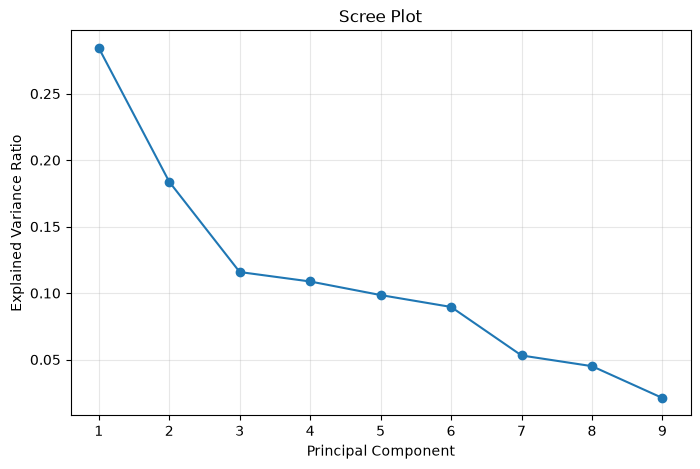

In [64]:
from sklearn.decomposition import PCA

pca = PCA()

X_pca = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(explained_variance) + 1),
    explained_variance,
    marker="o"
)

plt.xticks(range(1, len(explained_variance) + 1))
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.grid(alpha=0.3)

plt.show()

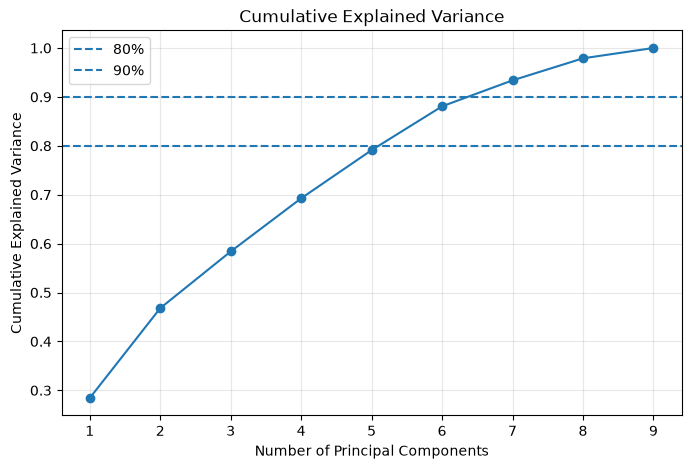

In [65]:
id="2w1l0d"
cumulative_variance=np.cumsum(explained_variance)

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.axhline(0.8, linestyle="--", label="80%")
plt.axhline(0.9, linestyle="--", label="90%")

plt.xticks(range(1, len(cumulative_variance) + 1))
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.grid(alpha=0.3)
plt.legend()

plt.show()

In [66]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(len(audio_features))],
    index=audio_features
)

loadings.round(3)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
acousticness,-0.503,-0.047,-0.307,0.063,-0.058,0.002,-0.144,0.733,0.291
danceability,-0.126,0.597,-0.069,-0.007,0.232,0.400,-0.592,-0.218,0.107
energy,0.570,0.015,0.143,-0.045,0.085,0.124,0.072,0.170,0.772
instrumentalness,-0.169,-0.274,0.528,0.230,0.618,0.353,0.086,0.184,-0.127
liveness,0.142,-0.245,-0.463,-0.421,0.657,-0.271,-0.141,-0.033,-0.047
loudness,0.523,0.165,0.136,-0.089,-0.090,-0.012,-0.301,0.566,-0.503
speechiness,0.205,-0.297,-0.517,0.108,-0.132,0.728,0.139,-0.029,-0.152
tempo,0.203,-0.098,-0.221,0.848,0.124,-0.308,-0.253,-0.078,0.018
valence,0.041,0.617,-0.229,0.157,0.285,-0.036,0.649,0.152,-0.111


Take PC1 and PC2 for visualization

In [67]:
pca_2 = PCA(n_components=2)

X_pca_2 = pca_2.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca_2,
    columns=["PC1", "PC2"]
)

pca_df.head()

,PC1,PC2
0,-0.925270,0.139859
1,1.638747,0.556613
2,0.953351,-0.714965
3,-2.430730,-0.508743
4,0.034831,1.397353


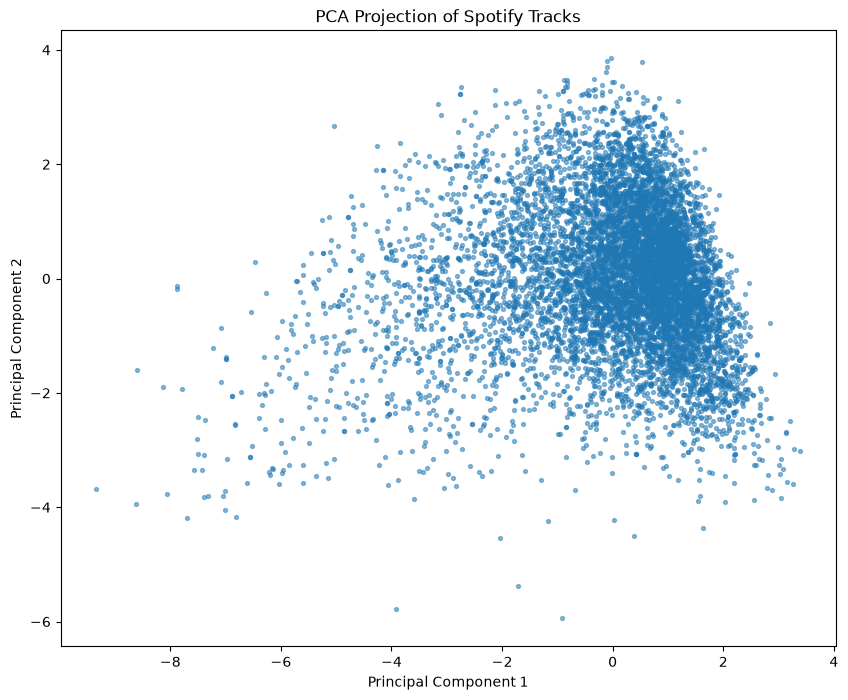

In [68]:
plt.figure(figsize=(10,8))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    s=8,
    alpha=0.5
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection of Spotify Tracks")

plt.show()

### PC1
Right: high energy, loudness

Left: calm, acousticness

### PC2
Top: euphoric, danceable

Bottom: instrumental, speachy

# K-Means

Use K-Means to find clusters with comparable audio features

In [69]:
from sklearn.cluster import KMeans

inertia = []

K = range(2, 11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

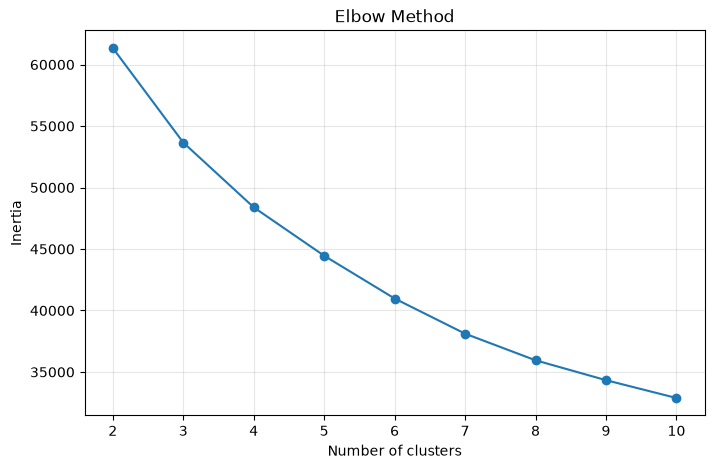

In [70]:
plt.figure(figsize=(8,5))

plt.plot(K, inertia, marker="o")

plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.grid(alpha=0.3)

plt.show()

In [71]:
from sklearn.metrics import silhouette_score

scores = []

for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    scores.append(
        silhouette_score(
            X_scaled,
            labels
        )
    )

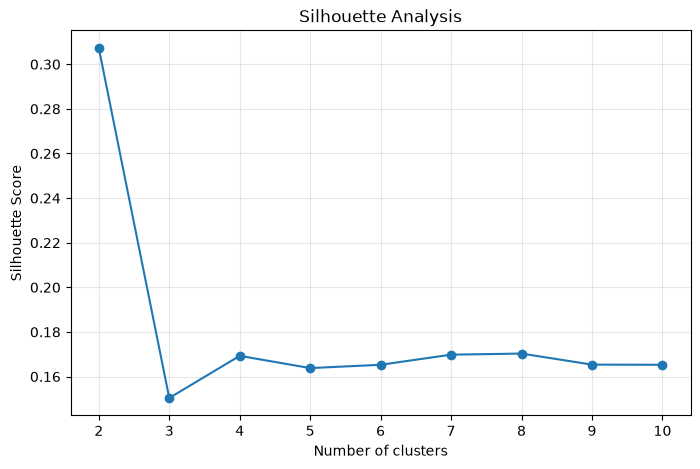

In [72]:
plt.figure(figsize=(8,5))

plt.plot(range(2,11), scores, marker="o")

plt.xlabel("Number of clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")

plt.grid(alpha=0.3)

plt.show()

The silhouette score indicates that two clusters provide the clearest mathematical separation. However, this division mainly distinguishes broad musical characteristics (e.g., acoustic vs. energetic tracks). To obtain more interpretable musical groups, we additionally explore a higher number of clusters, accepting a small decrease in cluster compactness in exchange for richer insights. First tests with k=7 have shown to much overlapping of artists in different clusters, so the number has been reduced to k=5.

### Train K-Means

In [73]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

labels = kmeans.fit_predict(X_scaled)

analysis_df["cluster"] = labels

pca_df["cluster"] = labels

Cluster plot

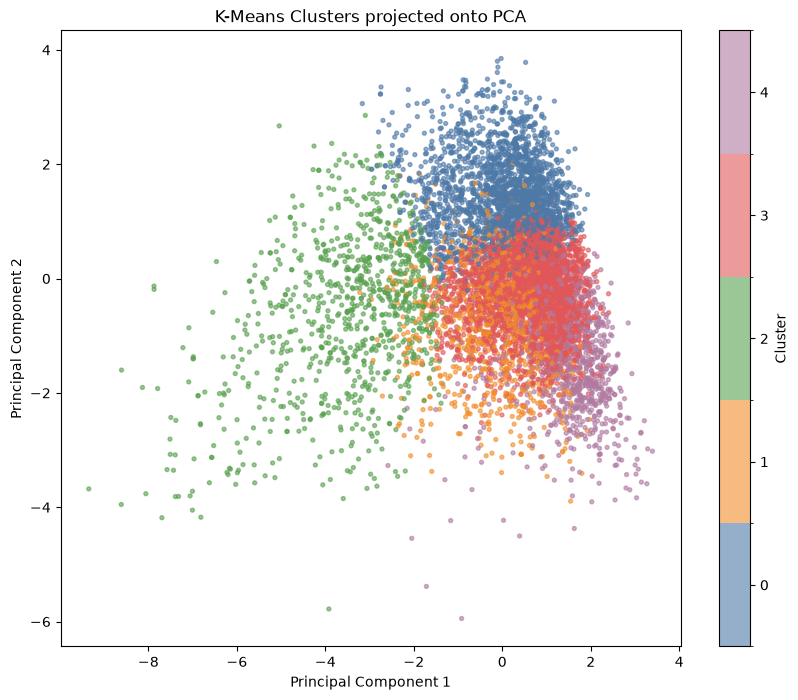

In [74]:
from matplotlib.colors import ListedColormap, BoundaryNorm

# Schöne, kontrastreiche Farben
colors = [
    "#4E79A7",  # blau
    "#F28E2B",  # orange
    "#59A14F",  # grün
    "#E15759",  # rot
    "#B07AA1",  # violett
]

cmap = ListedColormap(colors)
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5, 4.5], cmap.N)

plt.figure(figsize=(10,8))

scatter = plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["cluster"],
    cmap=cmap,
    norm=norm,
    s=8,
    alpha=0.6
)

cbar = plt.colorbar(
    scatter,
    ticks=[0,1,2,3,4]
)
cbar.set_label("Cluster")

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters projected onto PCA")

plt.show()

In [75]:
cluster_summary = analysis_df.groupby("cluster")[audio_features].mean()

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

heatmap_df = pd.DataFrame(
    scaler.fit_transform(cluster_summary),
    index=[f"Cluster {i}" for i in cluster_summary.index],
    columns=cluster_summary.columns
)

heatmap_df.index = range(len(heatmap_df))

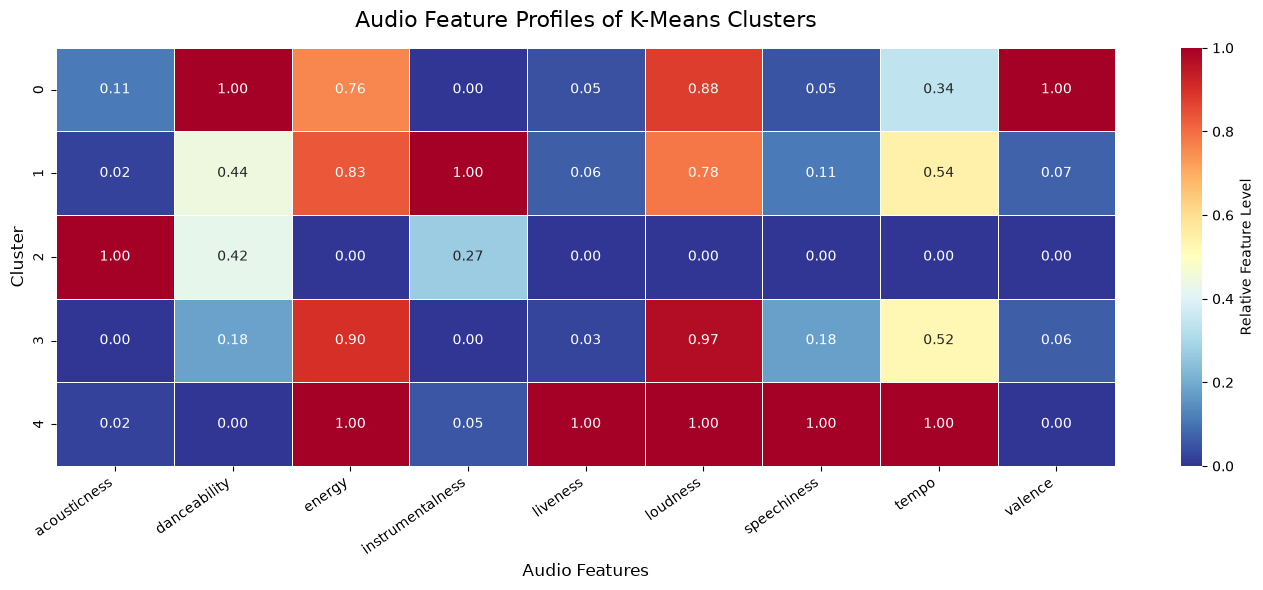

In [76]:
plt.figure(figsize=(14, 6))

sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".2f",
    cmap="RdYlBu_r",
    linewidths=0.5,
    cbar_kws={"label": "Relative Feature Level"}
)

plt.title(
    "Audio Feature Profiles of K-Means Clusters",
    fontsize=16,
    pad=15
)

plt.xlabel("Audio Features", fontsize=12)
plt.ylabel("Cluster", fontsize=12)

plt.xticks(rotation=35, ha="right")

plt.tight_layout()
plt.show()

In [77]:
cluster_sizes = (
    analysis_df["cluster"]
    .value_counts()
    .sort_index()
    .rename("Songs")
)

cluster_sizes

cluster
0    2264
1    1071
2     941
3    3230
4     898
Name: Songs, dtype: int64

Add track and artist names to the data frame, then display the top tracks and top artists for each cluster

In [78]:
df_music["track_id"] = df_music["spotify_track_uri"].str.split(":").str[-1]

track_info = (
    df_music[
        [
            "track_id",
            "master_metadata_track_name",
            "master_metadata_album_artist_name"
        ]
    ]
    .dropna(subset=["track_id"])
    .drop_duplicates(subset="track_id")
)

In [79]:
analysis_df = analysis_df.merge(
    track_info,
    on="track_id",
    how="left"
)


In [80]:
for cluster in sorted(analysis_df["cluster"].unique()):

    print(f"\n===== Cluster {cluster} =====")

    display(
        analysis_df.loc[
            analysis_df["cluster"] == cluster,
            [
                "master_metadata_track_name",
                "master_metadata_album_artist_name",
                "play_count"
            ]
        ]
        .sort_values("play_count", ascending=False)
        .head(10)
    )


===== Cluster 0 =====


,master_metadata_track_name,master_metadata_album_artist_name,play_count
8237,Equus 3,The Mars Volta,51
2885,Little Dark Age,MGMT,50
302,Allan Align,Drangsal,49
5224,Dance Macabre,Ghost,46
6973,Turmbau zu Babel,Drangsal,46
599,Ich will nicht nach Berlin,Kraftklub,46
7670,You're So Dark,Arctic Monkeys,46
2260,Exit Strategy,Drangsal,46
68,Magst Du mich (Oder magst Du bloß noch dein al...,Drangsal,46
7696,Jedem das Meine,Drangsal,45



===== Cluster 1 =====


,master_metadata_track_name,master_metadata_album_artist_name,play_count
7712,The Stargate [Tablet II],Blood Incantation,51
3466,Dead Meat,Shift,46
5608,The Stargate [Tablet III],Blood Incantation,46
6304,The Stargate [Tablet I],Blood Incantation,45
1901,The Message [Tablet II],Blood Incantation,35
1731,Rats,Ghost,32
552,The Message [Tablet III],Blood Incantation,31
4454,Sirenen,Drangsal,30
2959,Instant Crush (feat. Julian Casablancas),Daft Punk,30
124,Blankenship,DIIV,29



===== Cluster 2 =====


,master_metadata_track_name,master_metadata_album_artist_name,play_count
1751,The Ballad of Frankie Lee and Judas Priest,Bob Dylan,58
4393,Body Paint,Arctic Monkeys,50
4696,Big Ideas,Arctic Monkeys,40
4479,Shore Story,The Mars Volta,38
6993,Wearing The Inside Out - 2011 Remastered Version,Pink Floyd,33
2249,There’d Better Be A Mirrorball,Arctic Monkeys,32
5445,The Times They Are A-Changin',Bob Dylan,30
3169,Eine Geschichte,Drangsal,30
6179,Sculptures Of Anything Goes,Arctic Monkeys,29
6131,Mr Schwartz,Arctic Monkeys,29



===== Cluster 3 =====


,master_metadata_track_name,master_metadata_album_artist_name,play_count
5506,Katana,Enforcer,50
2680,In Absentia,The Mars Volta,45
2945,Deutschland,Rammstein,44
1298,Hell On Earth,Iron Maiden,42
6911,Graveyard Love,The Mars Volta,40
6864,Arche Gruber,Drangsal,38
370,Painkiller,Judas Priest,38
7171,Gloryhole,Steel Panther,38
7144,Vigil,The Mars Volta,37
2413,A View from the Top of the World,Dream Theater,36



===== Cluster 4 =====


,master_metadata_track_name,master_metadata_album_artist_name,play_count
8015,The Message [Tablet I],Blood Incantation,39
7779,Stratego,Iron Maiden,36
1225,Inertiatic Esp,The Mars Volta,36
2696,Collapsible Shoulders,The Mars Volta,34
2332,The Canary,Protest The Hero,32
6519,KFM,Die Ärzte,29
8318,Reverie,Protest The Hero,29
30,Darkest Hour,Iron Maiden,29
6277,Keine Angst (feat. Drangsal),Casper,28
2489,Bark at the Moon,Ozzy Osbourne,28


In [81]:
for cluster in sorted(analysis_df["cluster"].unique()):

    print(f"\n===== Cluster {cluster} =====")

    display(
        analysis_df.loc[analysis_df["cluster"] == cluster]
        .groupby("master_metadata_album_artist_name")["play_count"]
        .sum()
        .sort_values(ascending=False)
        .head(10)
        .reset_index()
    )


===== Cluster 0 =====


,master_metadata_album_artist_name,play_count
0,Arctic Monkeys,975
1,Von Wegen Lisbeth,879
2,Drangsal,831
3,Die Ärzte,804
4,Deep Purple,732
5,KISS,517
6,Kraftklub,504
7,AC/DC,480
8,The Mars Volta,402
9,Marilyn Manson,401



===== Cluster 1 =====


,master_metadata_album_artist_name,play_count
0,DIIV,477
1,TOOL,352
2,Blood Incantation,306
3,Polyphia,291
4,Skull Fist,225
5,Tame Impala,167
6,Sabïre,152
7,AC/DC,139
8,Ne Obliviscaris,138
9,SCHRAMM,135



===== Cluster 2 =====


,master_metadata_album_artist_name,play_count
0,Pink Floyd,607
1,The Mars Volta,435
2,Arctic Monkeys,384
3,Bob Dylan,325
4,Jesper Munk,222
5,Savatage,186
6,Jake Bugg,184
7,The Beatles,183
8,Drangsal,169
9,Black Sabbath,168



===== Cluster 3 =====


,master_metadata_album_artist_name,play_count
0,Iron Maiden,1127
1,Ozzy Osbourne,980
2,Dream Theater,743
3,Judas Priest,716
4,Deep Purple,672
5,Powerwolf,657
6,Marilyn Manson,629
7,Savatage,628
8,Pond,620
9,Helloween,501



===== Cluster 4 =====


,master_metadata_album_artist_name,play_count
0,The Mars Volta,695
1,Bring Me The Horizon,446
2,Marilyn Manson,313
3,Iron Maiden,259
4,Die Ärzte,240
5,Dream Theater,191
6,AC/DC,190
7,Protest The Hero,186
8,Asking Alexandria,181
9,Ozzy Osbourne,175


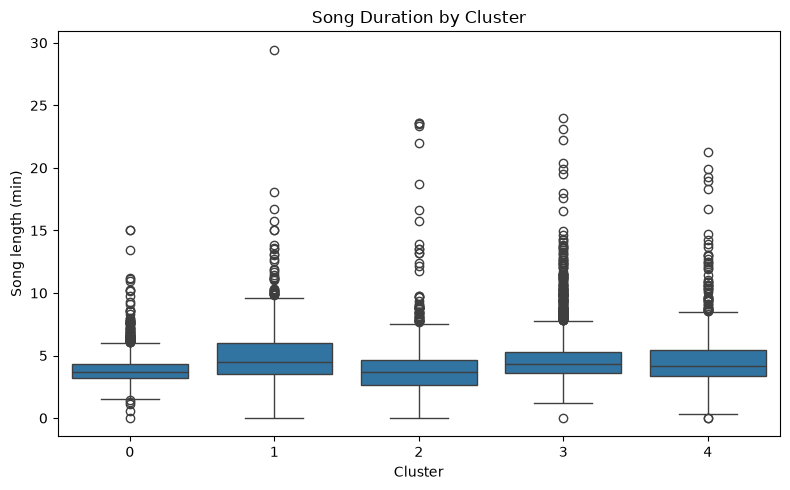

In [82]:
analysis_df["duration_min"] = analysis_df["duration_ms"] / 60000

plt.figure(figsize=(8,5))

sns.boxplot(
    data=analysis_df,
    x="cluster",
    y="duration_min"
)

plt.xlabel("Cluster")
plt.ylabel("Song length (min)")
plt.title("Song Duration by Cluster")

plt.tight_layout()
plt.show()

It is obvious that songs in cluster 0 are rather short, while songs in Cluster 2 tend to be long, with a wider distribution.

The clusters can be described with the following labels and characteristics:

| Cluster | Proposed Label | Characteristics | Representative Artists |
|:-------:|----------------|-----------------|------------------------|
| **0** | Indie & Punk Rock | High danceability, moderate energy, mainstream rock and indie influences | Arctic Monkeys, Von Wegen Lisbeth, Die Ärzte, AC/DC, KISS |
| **1** | Progressive & Technical Metal | Instrumental, complex song structures, high instrumentalness | TOOL, Polyphia, Blood Incantation, DIIV, Steve Vai |
| **2** | Psychedelic & Classic Rock | More acoustic and melodic, relaxed sound, classic rock influences | Pink Floyd, Bob Dylan, The Beatles, Jesper Munk |
| **3** | Heavy Metal | High energy and loudness, traditional heavy and progressive metal | Iron Maiden, Ozzy Osbourne, Judas Priest, Dream Theater, Helloween |
| **4** | Modern Metal & Experimental Rock | Aggressive, energetic, modern metal and post-hardcore characteristics | The Mars Volta, Bring Me The Horizon, Protest The Hero, Asking Alexandria |

In [83]:
df_music_clustered = df_music.merge(
    analysis_df[["track_id", "cluster"]],
    on="track_id",
    how="left"
)

monthly_cluster_minutes = (
    df_music_clustered
    .assign(
        month=df_music_clustered["ts"].dt.to_period("M").dt.to_timestamp(),
        minutes=df_music_clustered["ms_played"] / 60000
    )
    .groupby(["month", "cluster"])["minutes"]
    .sum()
    .unstack(fill_value=0)
)

yearly_cluster_minutes = (
    df_music_clustered
    .assign(
        year=df_music_clustered["ts"].dt.year,
        minutes=df_music_clustered["ms_played"] / 60000
    )
    .query("year >= 2018")
    .groupby(["year", "cluster"])["minutes"]
    .sum()
    .unstack(fill_value=0)
)

cluster_labels = {
    0: "Indie & Classic Rock",
    1: "Progressive / Technical Metal",
    2: "Psychedelic & Classic Rock",
    3: "Classic Heavy Metal",
    4: "Modern Metal"
}

C:\Users\sebas\AppData\Local\Temp\ipykernel_9264\1380441545.py:10: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  month=df_music_clustered["ts"].dt.to_period("M").dt.to_timestamp(),


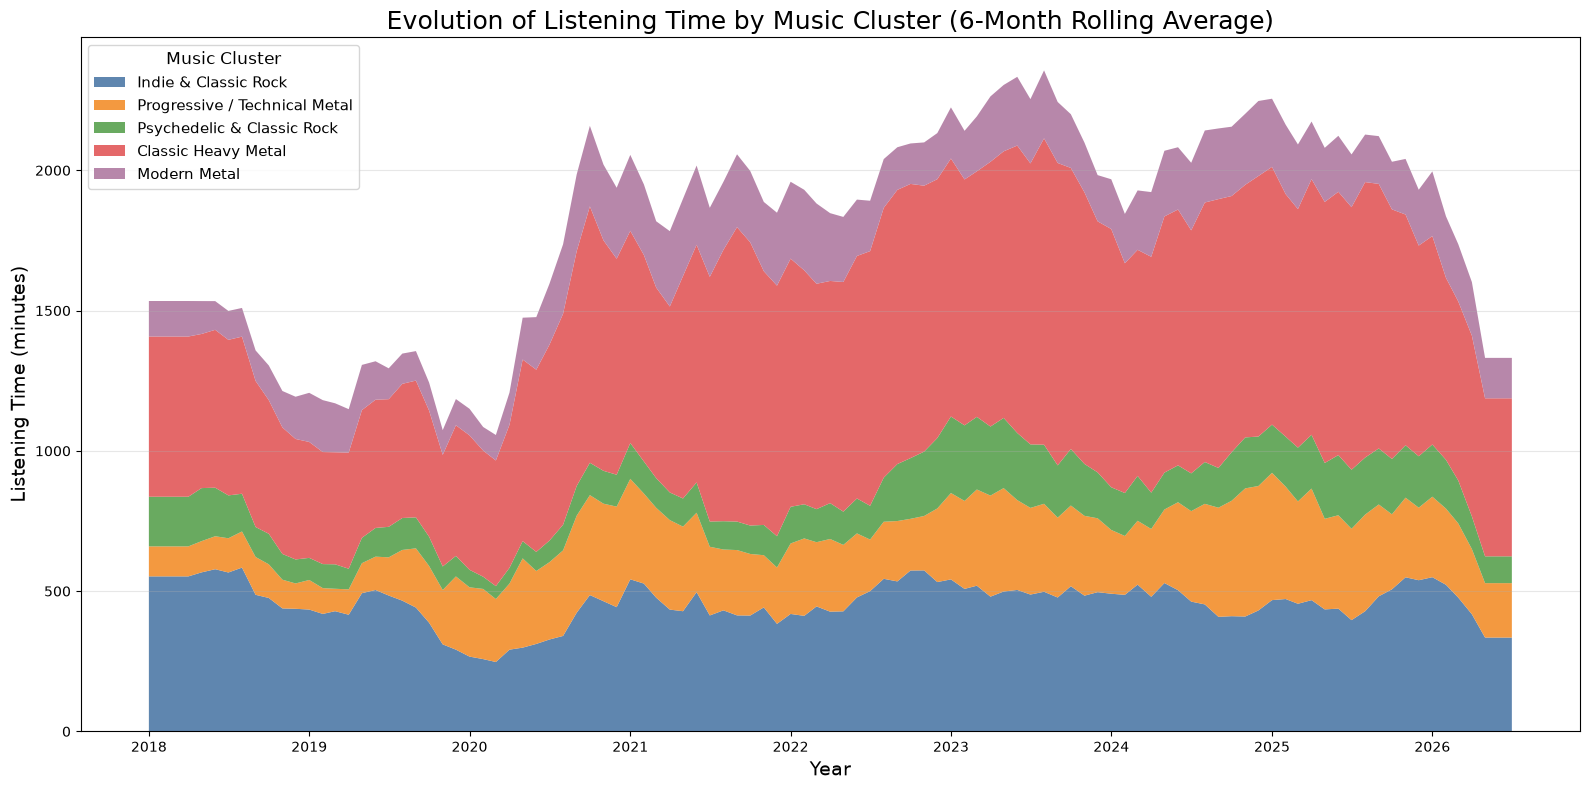

In [84]:

# Ab 2018
plot_data = monthly_cluster_minutes.loc["2018-01-01":]

# 6-Monats-Mittelwert
plot_data = plot_data.rolling(window=6, center=True).mean()

# Anfang/Ende auffüllen
plot_data = plot_data.bfill().ffill()

# Cluster umbenennen
plot_data = plot_data.rename(columns=cluster_labels)

# Farben
colors = [
    "#4E79A7",  # Blau
    "#F28E2B",  # Orange
    "#59A14F",  # Grün
    "#E15759",  # Rot
    "#B07AA1"   # Violett
]

plt.figure(figsize=(16,8))

plt.stackplot(
    plot_data.index,
    plot_data.T,
    labels=plot_data.columns,
    colors=colors,
    alpha=0.9
)

plt.title("Evolution of Listening Time by Music Cluster (6-Month Rolling Average)", fontsize=18)
plt.xlabel("Year", fontsize=14)
plt.ylabel("Listening Time (minutes)", fontsize=14)

plt.grid(axis="y", alpha=0.3)

plt.legend(
    title="Music Cluster",
    loc="upper left",
    fontsize=11,
    title_fontsize=12,
    frameon=True
)

plt.tight_layout()
plt.show()